<a href="https://colab.research.google.com/github/kshitij-nandanwar/NNDL-Lab/blob/main/NNDL_Practical_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Fashion MNIST Image Classification with CNN and Data Augmentation

This notebook demonstrates how to build and train a Convolutional Neural Network (CNN) for image classification on the Fashion MNIST dataset. It includes data preprocessing, model definition, training with data augmentation, evaluation using a confusion matrix, classifying new images, and visualizing feature maps.

### 1. Setup and Imports

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix
import seaborn as sns
from PIL import Image
import io
from google.colab import files

### 2. Load and Preprocess Fashion MNIST Dataset

In [ ]:
# Load the Fashion MNIST dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Reshape data to add a channel dimension (for grayscale images)
x_train = x_train.reshape((x_train.shape[0], 28, 28, 1))
x_test = x_test.reshape((x_test.shape[0], 28, 28, 1))

# Normalize pixel values to be between 0 and 1
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Convert labels to one-hot encoding
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

x_train shape: (60000, 28, 28, 1)
y_train shape: (60000, 10)
x_test shape: (10000, 28, 28, 1)
y_test shape: (10000, 10)


### 3. Define and Compile the CNN Model

In [ ]:
# Define the CNN model architecture
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

### 4. Data Augmentation Setup

In [ ]:
# Configure the ImageDataGenerator
datagen = ImageDataGenerator(
    rotation_range=10,         # Rotate images by a small degree (0-10 degrees)
    width_shift_range=0.1,     # Shift images horizontally by 10% of total width
    height_shift_range=0.1,    # Shift images vertically by 10% of total height
    shear_range=0.1,           # Apply shear transformations
    zoom_range=0.1,            # Zoom in/out by 10%
    horizontal_flip=True,      # Randomly flip images horizontally
    fill_mode='nearest'        # Fill in new pixels created by transformations
)

# Fit the data generator to the training data
datagen.fit(x_train)

print("ImageDataGenerator configured and fitted to training data.")

ImageDataGenerator configured and fitted to training data.


### 5. Train and Evaluate the Model with Data Augmentation

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 34s 16ms/step - accuracy: 0.7553 - loss: 0.6497 - val_accuracy: 0.8335 - val_loss: 0.4464
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.8254 - loss: 0.4628 - val_accuracy: 0.8508 - val_loss: 0.3980
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.8439 - loss: 0.4139 - val_accuracy: 0.8700 - val_loss: 0.3567
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - accuracy: 0.8543 - loss: 0.3847 - val_accuracy: 0.8777 - val_loss: 0.3345
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.8628 - loss: 0.3652 - val_accuracy: 0.8676 - val_loss: 0.3675
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.8691 - loss: 0.3494 - val_accuracy: 0.8889 - val_loss: 0.3063
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.8738 - loss: 0.3349 - val_accuracy: 0.8825 - val_loss: 0.3230
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.8773 -

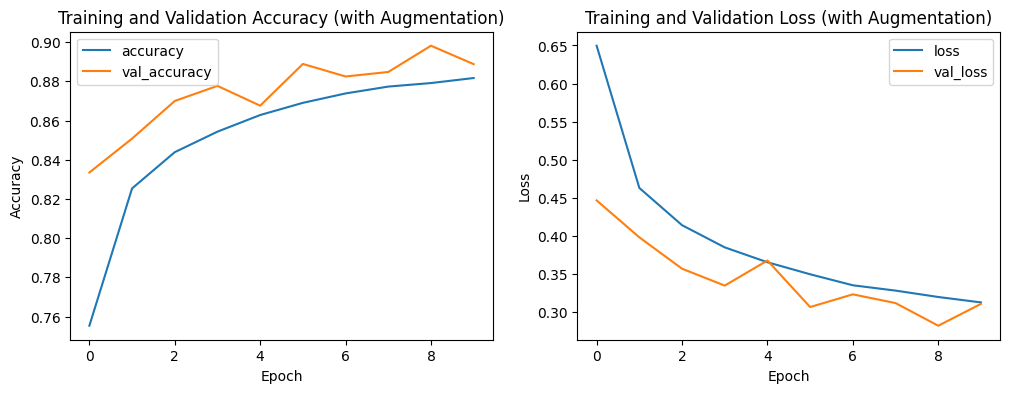

In [ ]:
# Train the model with data augmentation
history = model.fit(datagen.flow(x_train, y_train, batch_size=32),
                              epochs=10,
                              validation_data=(x_test, y_test),
                              steps_per_epoch=len(x_train) // 32)

# Evaluate the model on the test set
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Test Loss (with augmentation): {loss:.4f}")
print(f"Test Accuracy (with augmentation): {accuracy:.4f}")

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy (with Augmentation)')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss (with Augmentation)')
plt.show()

### 6. Generate Confusion Matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


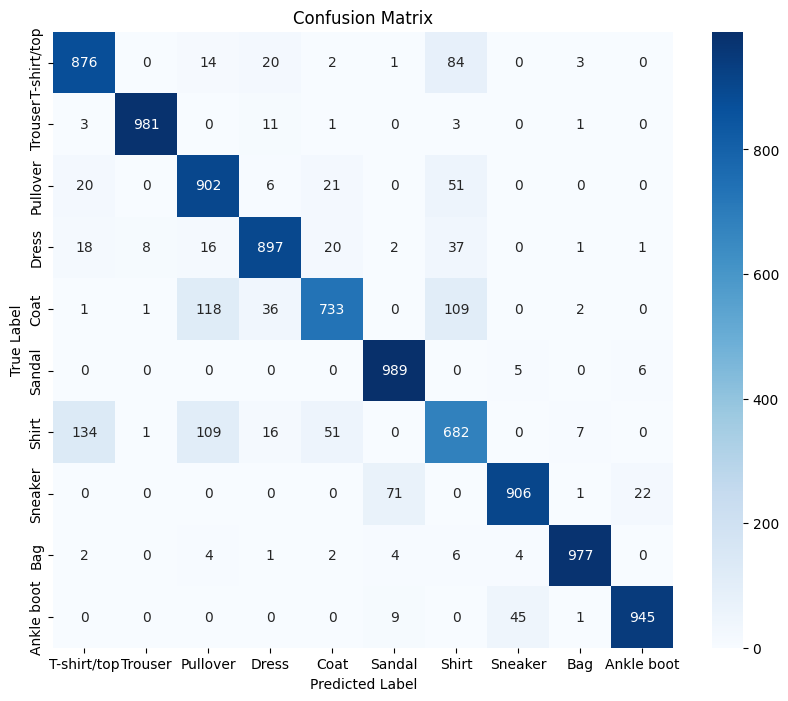

In [ ]:
# Define Fashion MNIST class names
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Get predictions for the test set
y_pred_prob = model.predict(x_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# Convert one-hot encoded y_test to categorical labels
y_true = np.argmax(y_test, axis=1)

# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### 7. Classify New Images

In [ ]:
def preprocess_image(image_path):
    img = Image.open(image_path).convert('L')  # Convert to grayscale
    img = img.resize((28, 28)) # Resize to 28x28 pixels
    img_array = np.array(img).astype('float32') / 255.0 # Normalize
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array = np.expand_dims(img_array, axis=-1) # Add channel dimension
    return img_array

print("Image preprocessing function defined.")

Image preprocessing function defined.


Now, you can run the following cell to upload an image and get a classification prediction. Choose an image file from your local machine (e.g., a `.png` or `.jpg` file).

Saving boot.jpeg to boot (1).jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step

Uploaded file: boot (1).jpeg
Predicted class: Ankle boot (Confidence: 99.68%)


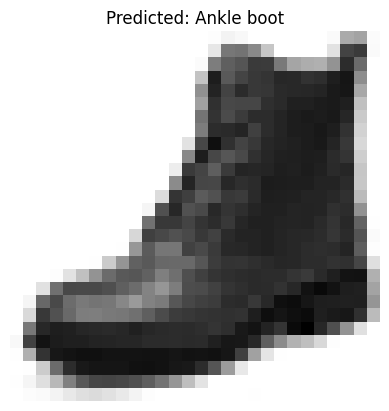

In [ ]:
from google.colab import files
import io

# Upload an image file
uploaded = files.upload()

# Assuming only one file is uploaded
for fn in uploaded.keys():
    image_path = io.BytesIO(uploaded[fn])
    preprocessed_img = preprocess_image(image_path)

    # Make prediction
    predictions = model.predict(preprocessed_img)
    predicted_class_index = np.argmax(predictions[0])
    predicted_class_name = class_names[predicted_class_index]

    print(f"\nUploaded file: {fn}")
    print(f"Predicted class: {predicted_class_name} (Confidence: {predictions[0][predicted_class_index]*100:.2f}%)")

    # Display the image for verification
    plt.imshow(preprocessed_img.squeeze(), cmap='gray')
    plt.title(f"Predicted: {predicted_class_name}")
    plt.axis('off')
    plt.show()

### 8. Visualize Feature Maps

In [ ]:
def visualize_feature_maps(model, image, layer_names):
    # Create a model that outputs the activations of the specified layers
    activation_models = []
    for layer_name in layer_names:
        # Ensure the layer exists and is a Conv2D layer
        try:
            layer_output = model.get_layer(layer_name).output
            # Use model.layers[0].input for Sequential models to ensure input is defined
            activation_models.append(Model(inputs=model.layers[0].input, outputs=layer_output))
        except ValueError:
            print(f"Warning: Layer '{layer_name}' not found or not a valid layer for feature map visualization.")
            continue

    if not activation_models:
        print("No valid convolutional layers found for feature map visualization.")
        return

    # Preprocess the image if not already done (e.g., expand dimensions, normalize)
    if image.ndim == 3:
        image = np.expand_dims(image, axis=0) # Add batch dimension
    if image.shape[-1] == 1:
        image = image # Already has channel dimension for grayscale
    elif image.ndim == 2: # Handle 2D grayscale image without channel dimension
        image = np.expand_dims(image, axis=-1)
        image = np.expand_dims(image, axis=0)

    # Generate feature maps for each layer
    for i, activation_model in enumerate(activation_models):
        layer_name = layer_names[i]
        activations = activation_model.predict(image)
        num_filters = activations.shape[-1]

        # Calculate grid dimensions
        grid_size = int(np.ceil(np.sqrt(num_filters)))

        plt.figure(figsize=(grid_size * 2, grid_size * 2))
        plt.suptitle(f'Feature Maps for Layer: {layer_name}', fontsize=16)

        for j in range(num_filters):
            ax = plt.subplot(grid_size, grid_size, j + 1)
            plt.imshow(activations[0, :, :, j], cmap='viridis')
            plt.axis('off')
        plt.show()

print("Feature map visualization function defined.")

Feature map visualization function defined.


Let's visualize the feature maps for the first image in the test set after it has been preprocessed.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step


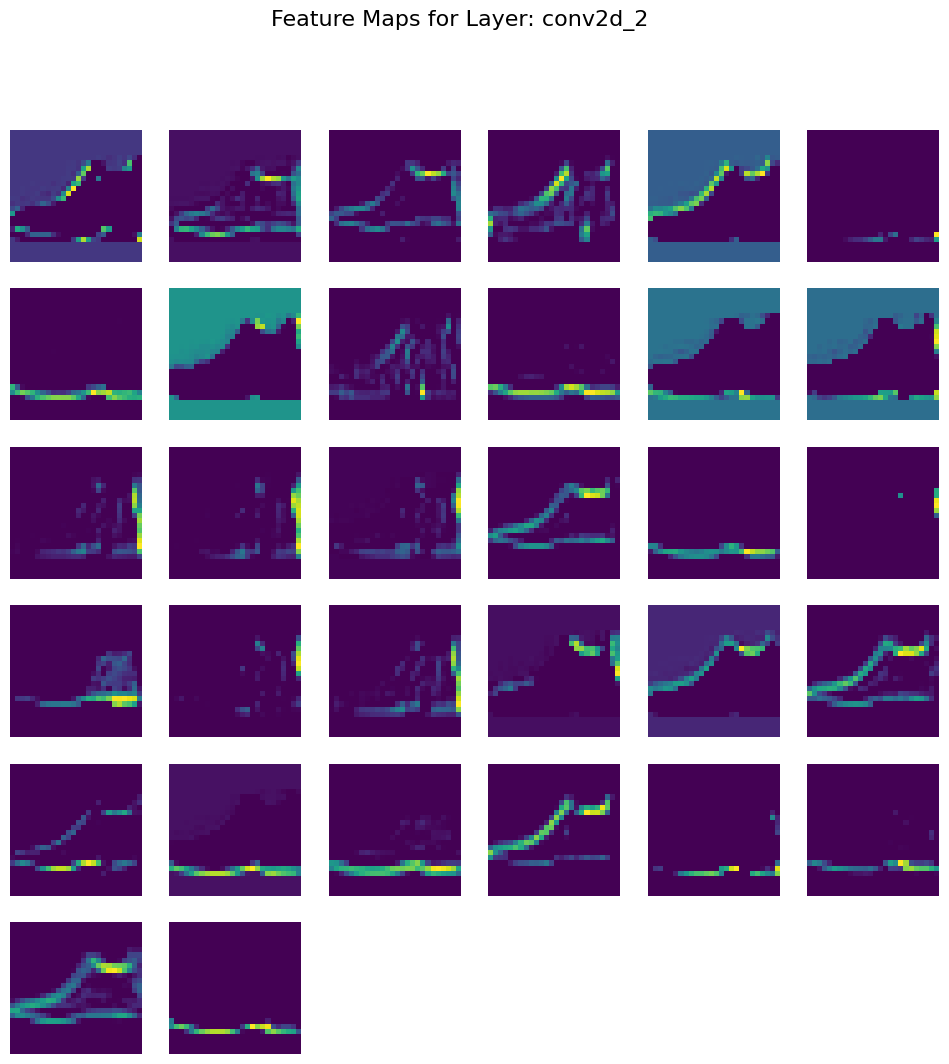

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step


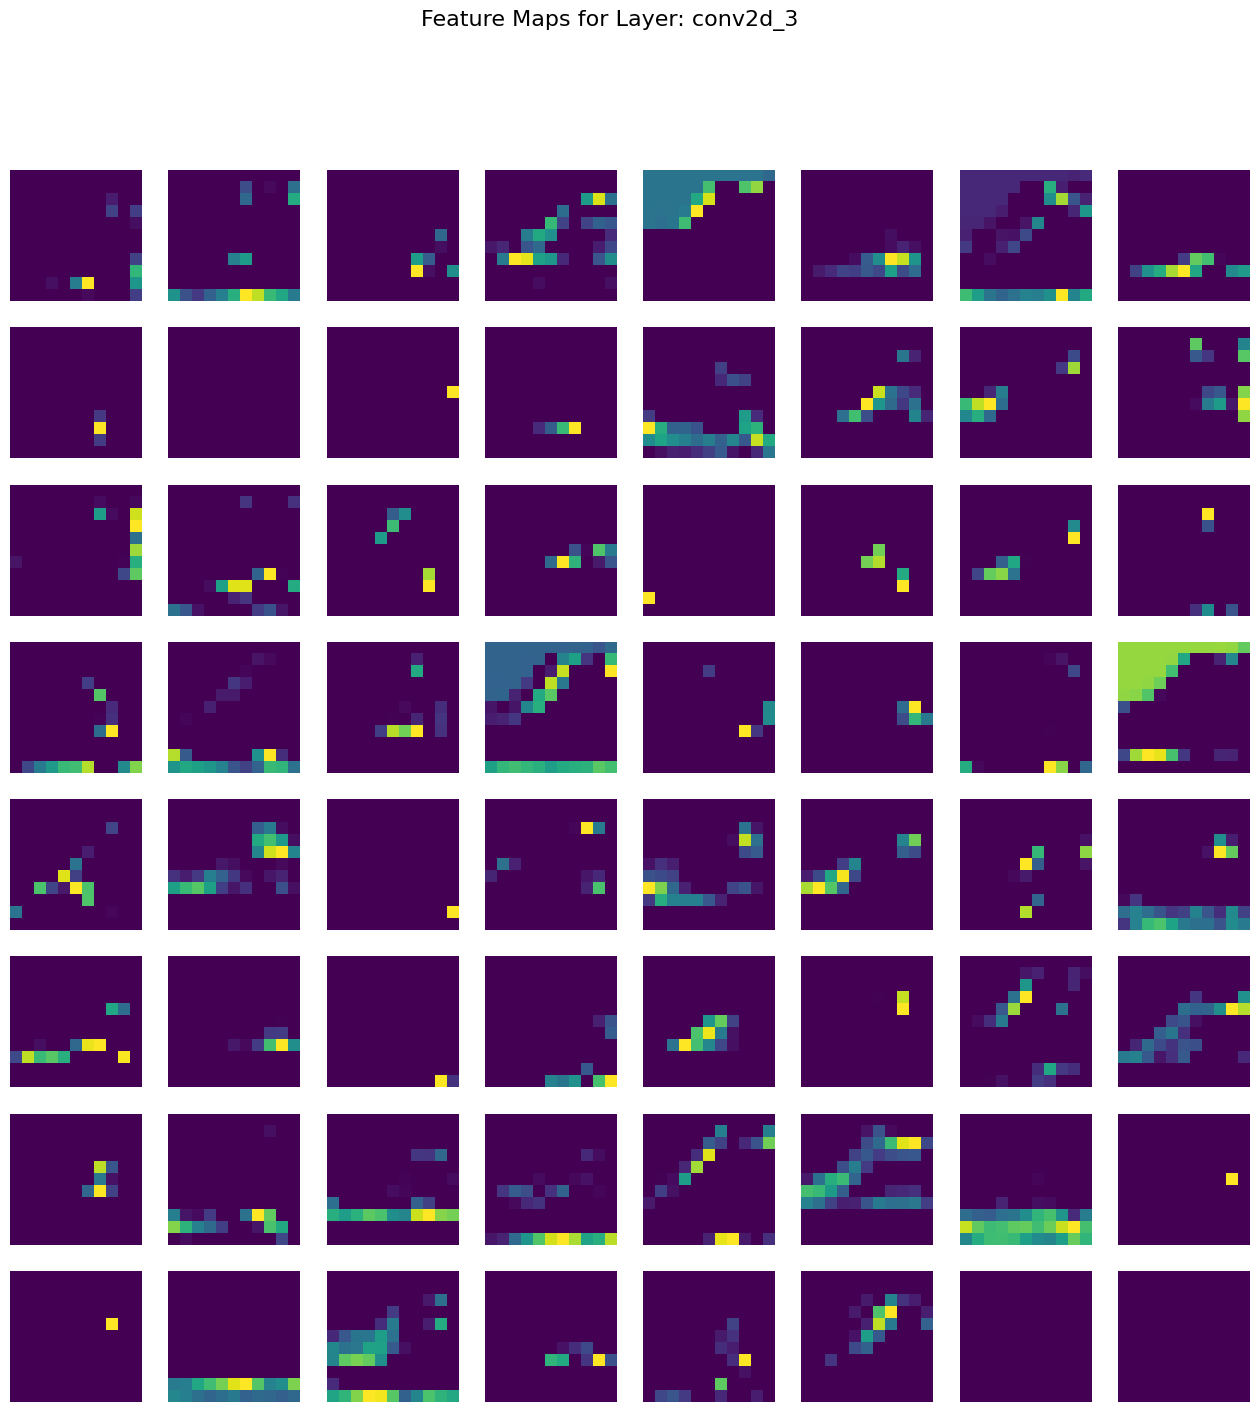

In [ ]:
# Select a sample image from the test set
sample_image = x_test[0]

# Get the names of the convolutional layers in your model
conv_layer_names = []
for layer in model.layers:
    if isinstance(layer, Conv2D):
        conv_layer_names.append(layer.name)

# Visualize feature maps for the convolutional layers
visualize_feature_maps(model, sample_image, conv_layer_names)